In [1]:
import pandas as pd
import numpy as np
import random as rnd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import datasets

In [2]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv("pima-indians-diabetes.data.csv", names=cols)

In [4]:

# Xử lý missing values (0 -> NaN)
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Điền giá trị thiếu bằng mean
df.fillna(df.mean(), inplace=True)

# Tách input / output
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [6]:
data_df = df.copy()
data_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1


In [7]:
model = DecisionTreeClassifier(max_depth=4, )

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = model.predict(X_test)

print(f"Classification report for DecisionTree:\n"
f"{metrics.classification_report(y_test, y_pred)}\n")

Classification report for DecisionTree:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       125
           1       0.65      0.61      0.63        67

    accuracy                           0.75       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.75      0.75      0.75       192




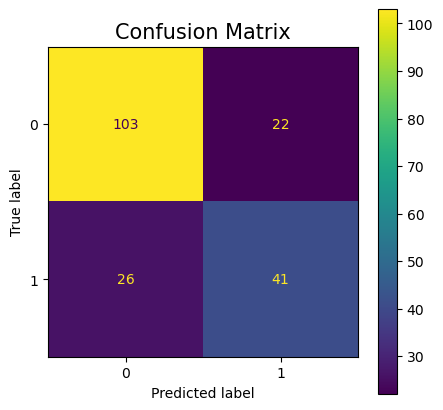

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay


plt.figure(figsize=(5, 5))
ax = plt.gca()

disp = ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, ax=ax
)

plt.title("Confusion Matrix", fontsize=15)
plt.show()

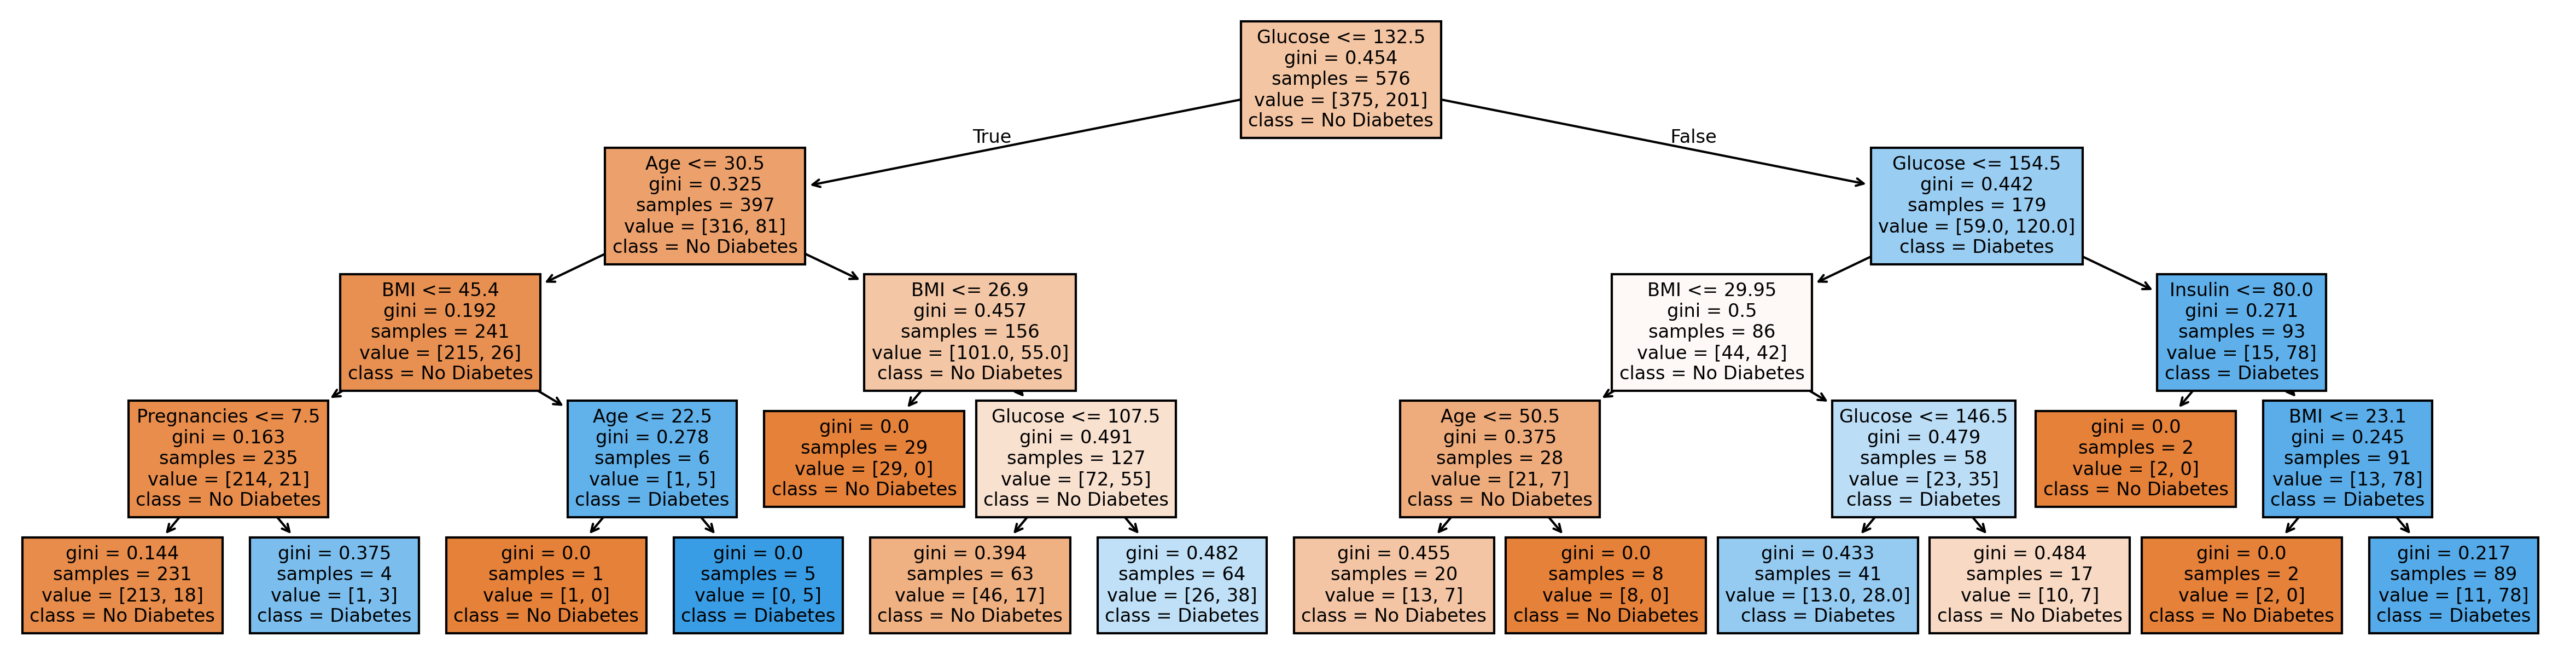

In [12]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), dpi=300)

tree.plot_tree(
    model,
    feature_names=cols[:-1],  # bỏ 'Outcome'
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.show()

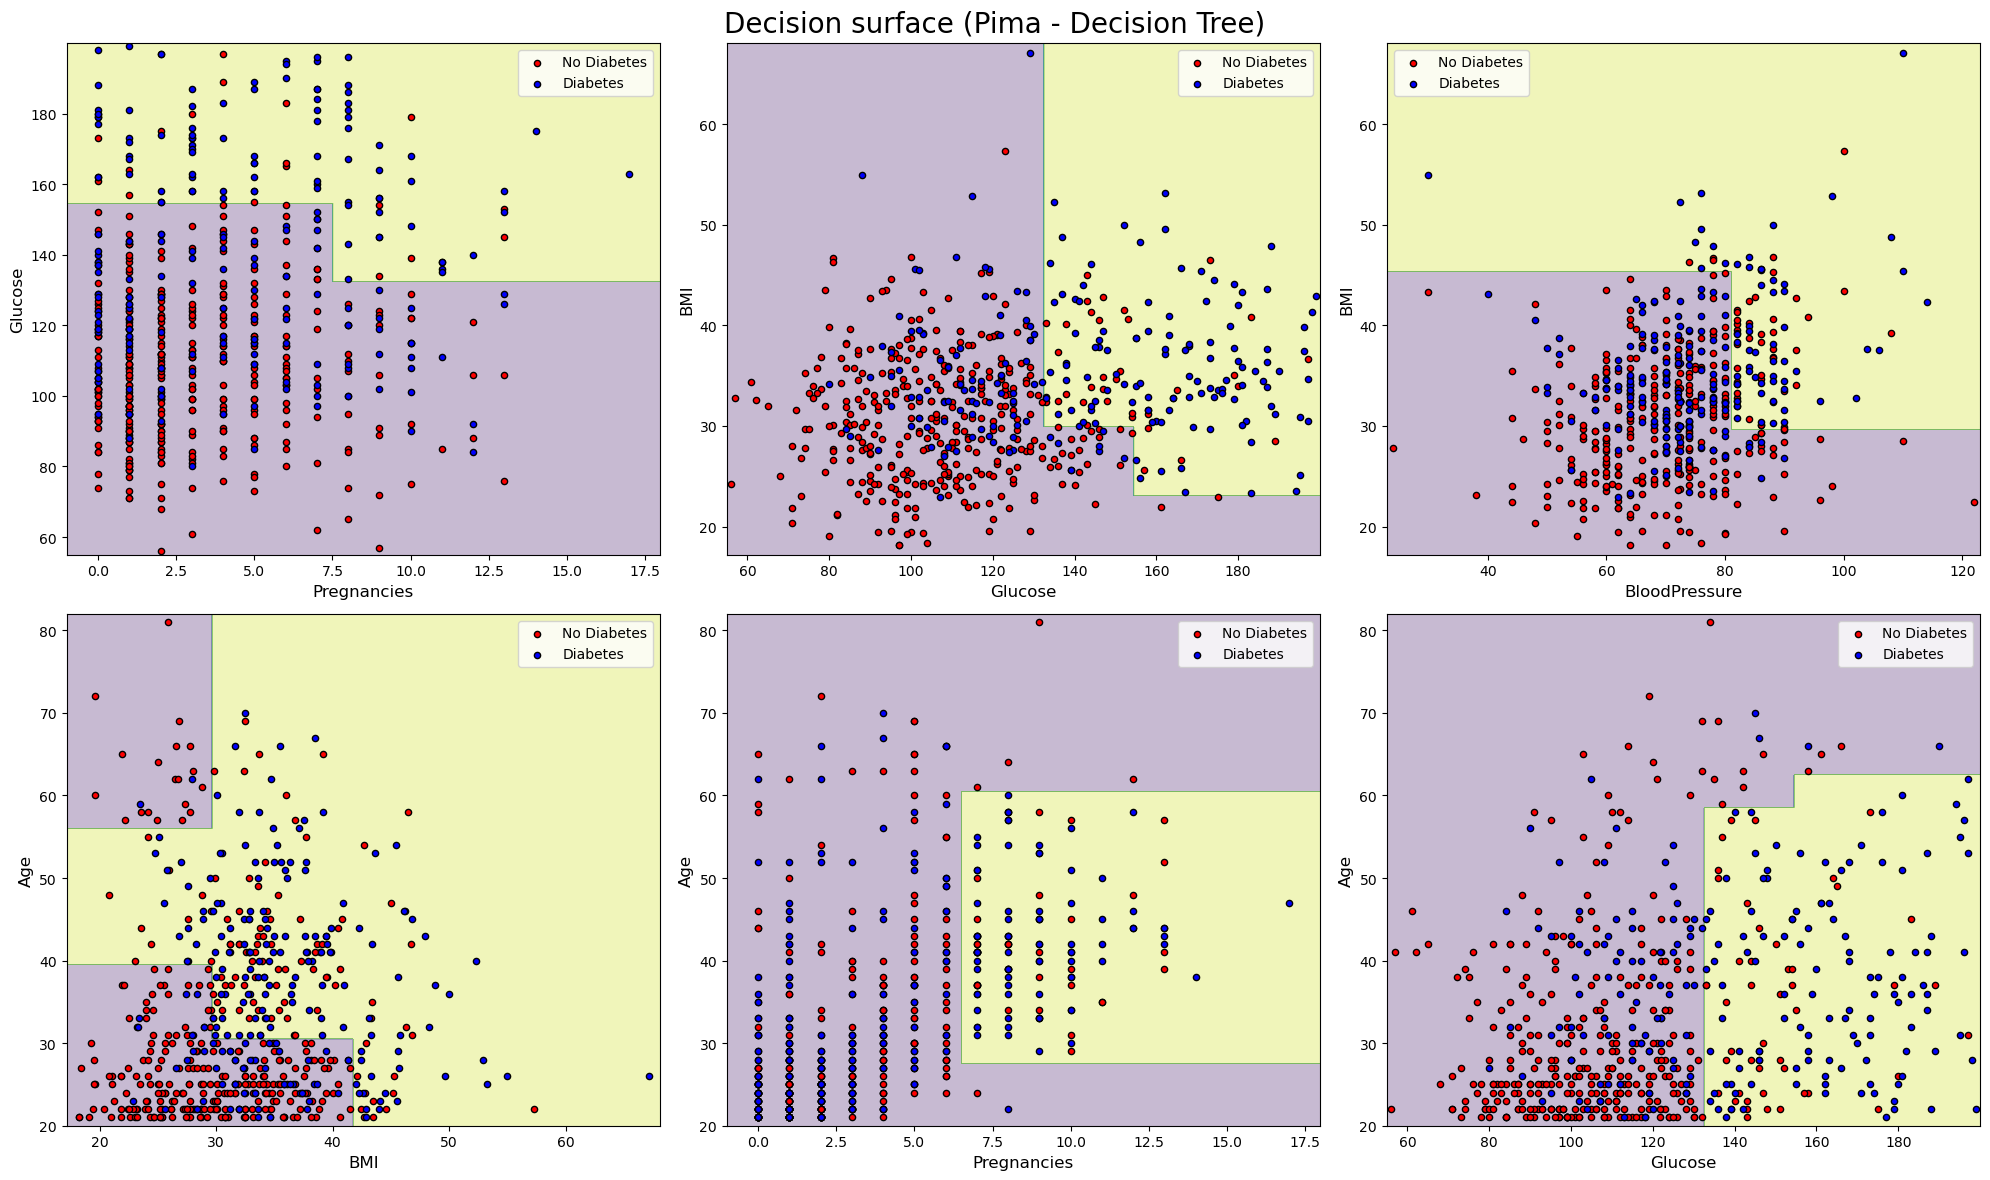

In [13]:
n_classes = 2
plot_colors = "rb"
plot_step = 0.02

font = {'size': 12}

plt.figure(figsize=(20, 12))
plt.suptitle("Decision surface (Pima - Decision Tree)", size=20)

# chọn các cặp feature
pairs = [[0, 1], [1, 5], [2, 5], [5, 7], [0, 7], [1, 7]]

for pairidx, pair in enumerate(pairs):
    plt.subplot(2, 3, pairidx + 1)

    # lấy 2 feature
    X_pair = X_train.iloc[:, pair].values

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_pair, y_train)

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    # label trục
    plt.xlabel(cols[pair[0]], **font)
    plt.ylabel(cols[pair[1]], **font)

    # vẽ điểm
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y_train == i)
        plt.scatter(
            X_pair[idx, 0], X_pair[idx, 1],
            c=color,
            label=["No Diabetes", "Diabetes"][i],
            edgecolor='black',
            s=20
        )

    plt.legend()

plt.tight_layout()
plt.show()